<a href="https://colab.research.google.com/github/darthnylus/frame-chime-clone/blob/main/Avocado_Machine_Learning_Project_Python_for_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🥑 AVOCADO PRICE FORECASTING: COMPARATIVE ANALYSIS
## Machine Learning (AdaBoost) vs. Time Series (Prophet & ARIMA)

Imagine you have a magic crystal ball that predicts the price of avocados at the grocery store!

---

### 📌 How the App Works Step-by-Step

#### **Step 1: Learn from the past**
The app looks at avocado prices from **2015 to 2018**—like reading a diary of *"how much did avocados cost each week?"* It notices key patterns:
* **Seasonality:** Avocados are more expensive in winter (when they're harder to grow).
* **Category:** Organic avocados always cost more than regular ones.
* **Geography:** Different cities pay different prices.

---

#### **Step 2: Use three different "fortune tellers"**
The app doesn't just use one method to guess the future—it uses three distinct algorithms:

1. 🕵️‍♂️ **AdaBoost** *(The "Detail Detective")*  
   Looks at **all** the clues: volume sold, city, type, and month. It's like Sherlock Holmes noticing every tiny detail to make a precise guess.
2. 🔮 **Prophet** *(The "Pattern Finder")*  
   Finds big, obvious patterns—like *"every winter is cold, every summer is hot."* It’s simple but exceptional at spotting big repeating cycles.
3. 🧮 **ARIMA** *(The "Number Cruncher")*  
   Uses math to look at what *just* happened and predicts what comes next. (e.g., *if the price went up this week, it might stay high next week*).

---

#### **Step 3: See which one is best**
The app tests all three models on historical hold-out prices (data they haven't seen during training), then checks: **which guess was closest to the real price?** It measures performance using standard error scores (`MAE` and `MAPE`).

---

#### **Step 4: Pick the winner (or combine them)**
If one method wins, we deploy that model. However, the app can also recommend a **hybrid strategy**:
> *"Use Prophet for planning stock in stores next quarter, and use AdaBoost when you need to predict the price right now in New York."*

---

### 💡 In Simple Terms
The app is like having **three different friends** who are good at guessing games:
* **Friend 1 (AdaBoost):** Studies everything in detailed granularity.
* **Friend 2 (Prophet):** Remembers macro trends and what usually happens every year.
* **Friend 3 (ARIMA):** Looks closely at recent momentum to guess what happens next.

*You test all three, see who guesses best, and know exactly which friend to trust for specific decisions!*

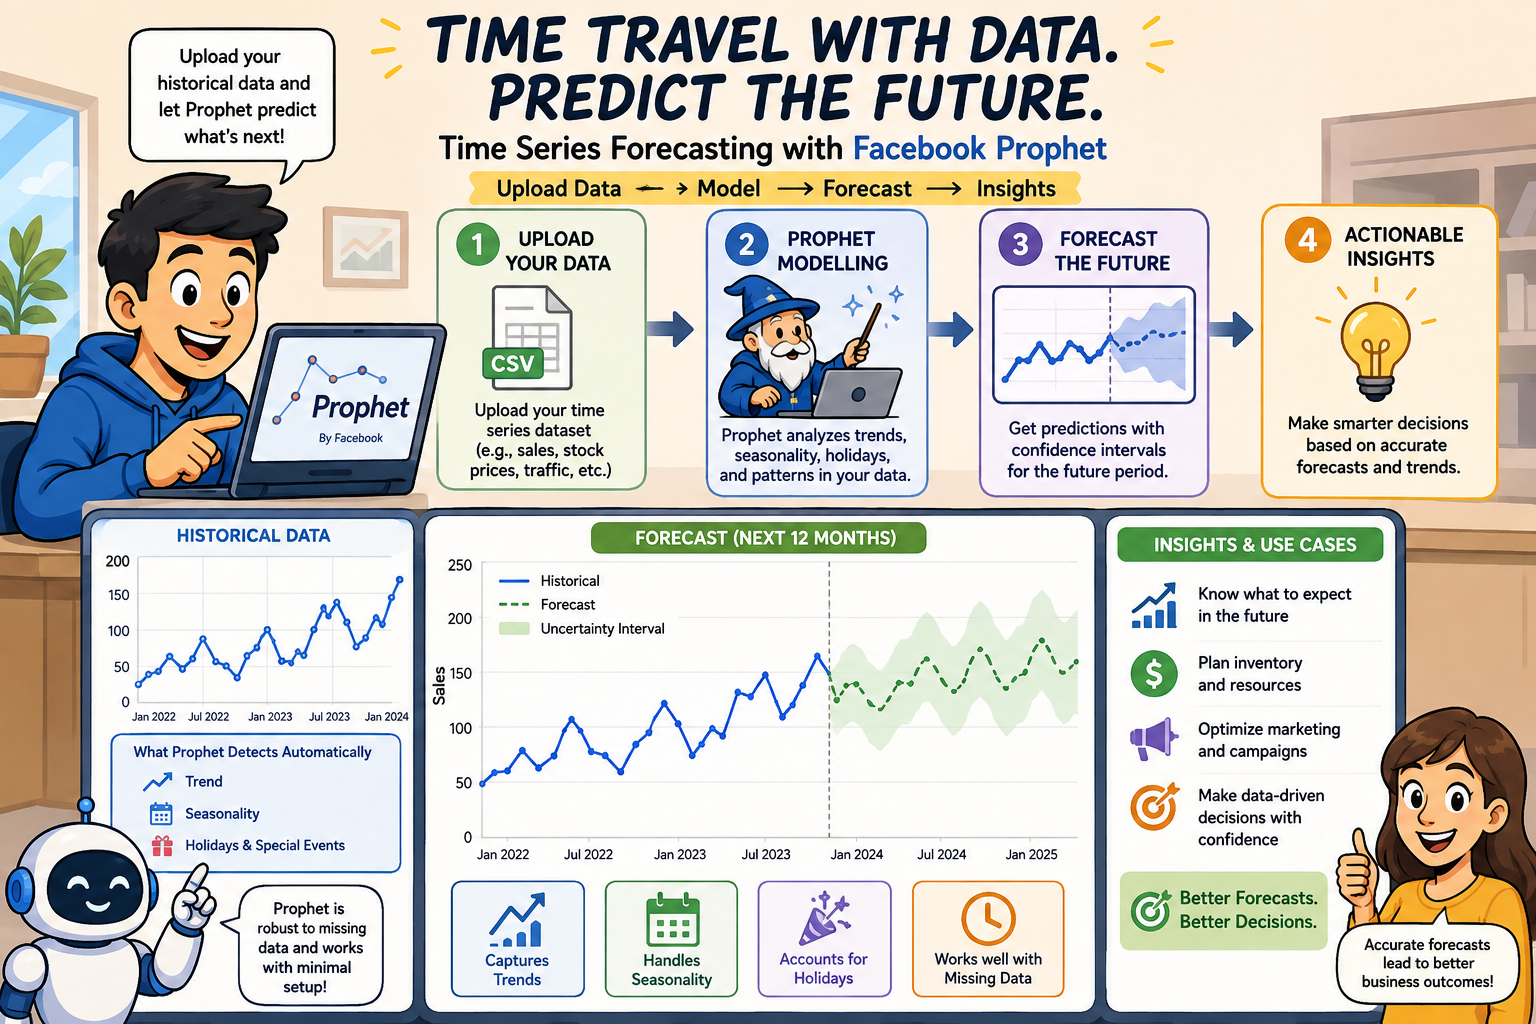

Libraries successfully loaded.
Dataset Shape: (1690, 13)
Data Summary Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1690 entries, 0 to 1689
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1690 non-null   datetime64[ns]
 1   AveragePrice  1690 non-null   float64       
 2   Total Volume  1690 non-null   float64       
 3   4046          1690 non-null   float64       
 4   4225          1690 non-null   float64       
 5   4770          1690 non-null   float64       
 6   Total Bags    1690 non-null   float64       
 7   Small Bags    1690 non-null   float64       
 8   Large Bags    1690 non-null   float64       
 9   XLarge Bags   1690 non-null   float64       
 10  type          1690 non-null   object        
 11  year          1690 non-null   int64         
 12  region        1690 non-null   object        
dtypes: datetime64[ns](1), float64(9), int64(1), object(2)
memory u

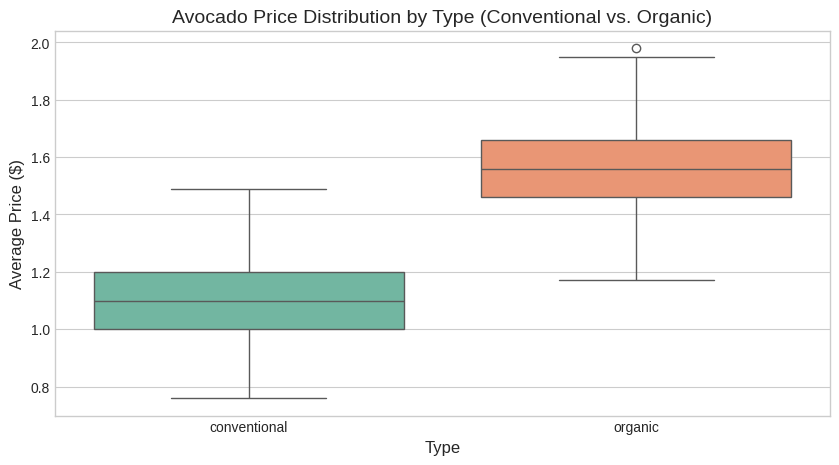

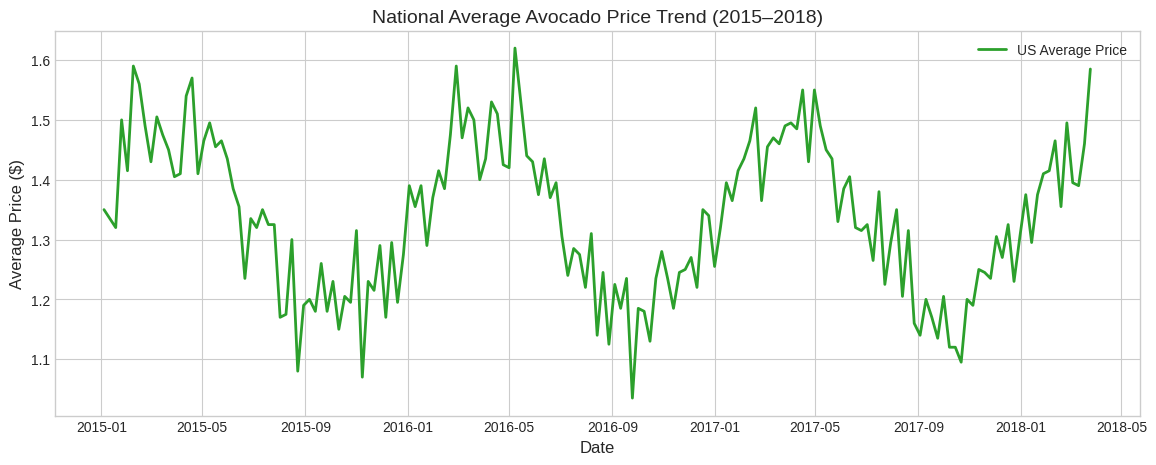

Train features shape: (1352, 14)
Test features shape: (338, 14)
Optimal Hyperparameters: {'learning_rate': 0.03, 'n_estimators': 100}
Mean Absolute Error (MAE): $0.0676
Mean Absolute Percentage Error (MAPE): 5.25%
Mean Absolute Error (MAE): $0.0433
Mean Absolute Percentage Error (MAPE): 3.12%


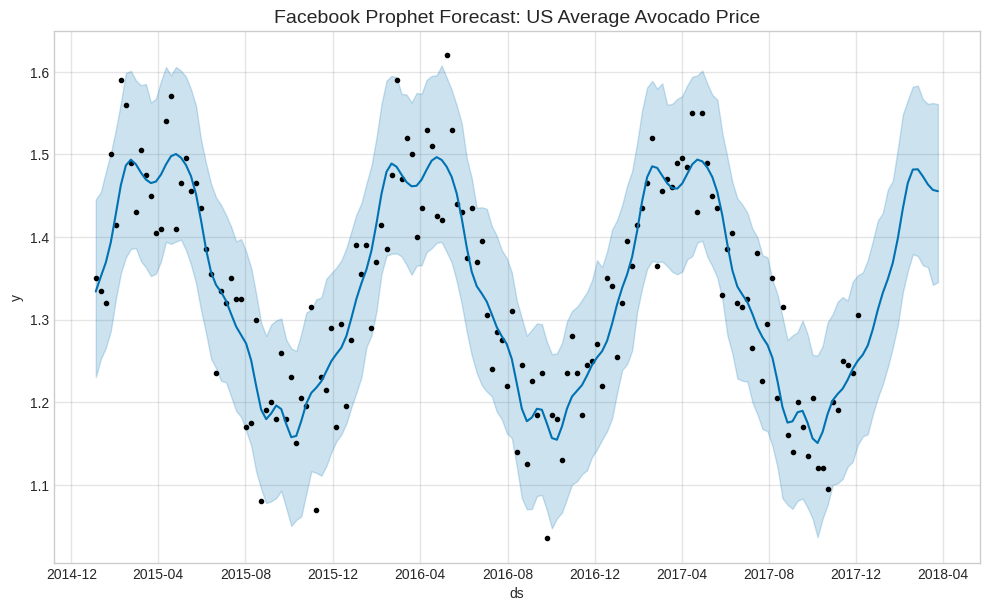

ADF Statistic: -4.4026
p-value: 0.0003
Mean Absolute Error (MAE): $0.1180
Mean Absolute Percentage Error (MAPE): 8.21%
 MODEL PERFORMANCE COMPARISON 


,Model,MAE ($),MAPE (%)
0,AdaBoost Regressor (tabular),0.067586,5.252133
1,Facebook Prophet (time series),0.043293,3.122883
2,ARIMA (time series),0.117997,8.213246


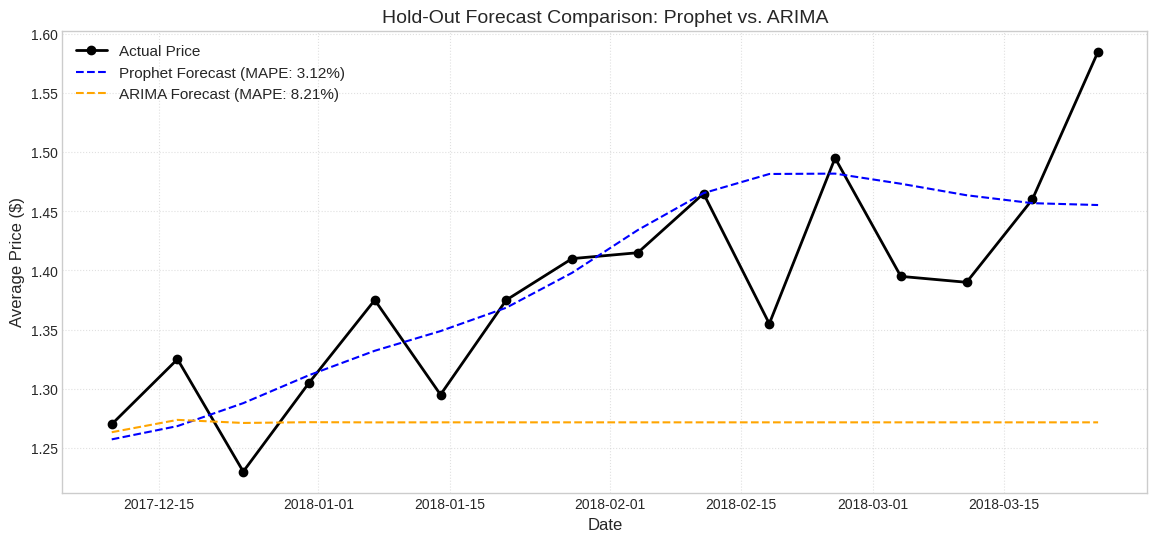

In [ ]:

# ===========================================================================
# CELL 2: SETUP & LIBRARY IMPORTS
# ===========================================================================
# Load all required dependencies for data processing, ML modeling,
# time series forecasting, and visualization.

import warnings
warnings.filterwarnings('ignore')

# Data manipulation & numerical computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Scikit-Learn: preprocessing, model selection, tree-based ensembles, metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)

# Time Series Forecasting: statistical tests, ARIMA, Prophet
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

# Configure matplotlib for inline display and consistent styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in
plt.style.available else 'default')
%matplotlib inline

print("Libraries successfully loaded.")


# ===========================================================================
# CELL 3: DATA LOAD & SYNTHETIC DATA GENERATION
# ===========================================================================
# Generate a synthetic avocado dataset with realistic seasonal patterns,
# regional variation, and type-based pricing (conventional vs. organic).
# This simulates weekly aggregated sales data from 2015-2018.

def generate_avocado_dataset(seed=42):
    """
    Create a realistic synthetic avocado dataset with:
    - Weekly timestamps (Sunday aggregation)
    - 5 regions (TotalUS, California, NewYork, Chicago, Orlando)
    - 2 product types (conventional, organic)
    - Volume breakdown by PLU codes and bag sizes
    - Seasonal price fluctuations
    """
    np.random.seed(seed)

    # Define time range: weekly data from Jan 2015 to Mar 2018
    date_range = pd.date_range(start='2015-01-04', end='2018-03-25', freq='W-SUN')

    # Define regional and product segments
    regions = ['TotalUS', 'California', 'NewYork', 'Chicago', 'Orlando']
    types = ['conventional', 'organic']

    data = []

    # Generate one row per (date, region, type) combination
    for date in date_range:
        for region in regions:
            for avocado_type in types:
                # ---- Price Modeling ----
                # Apply seasonal effect: prices spike in winter (low supply)
                day_of_year = date.dayofyear
                seasonal_effect = 0.15 * np.sin(2 * np.pi * day_of_year / 365)

                # Organic avocados command ~45% premium over conventional
                type_premium = 0.45 if avocado_type == 'organic' else 0.0

                # Combine base price + premium + seasonal variation + noise
                base_price = 1.10 + type_premium + seasonal_effect + np.random.normal(0, 0.08)

                # ---- Volume Modeling ----
                # Non-TotalUS regions: smaller volumes; TotalUS is aggregate of all regions
                total_vol = (
                    np.random.uniform(50000, 5000000)
                    if region != 'TotalUS'
                    else np.random.uniform(20000000, 45000000)
                )

                # Distribute total volume across PLU codes (size classifications)
                # PLU 4046: large, PLU 4225: medium, PLU 4770: extra-small
                plu_4046 = total_vol * np.random.uniform(0.3, 0.4)  # ~35% large
                plu_4225 = total_vol * np.random.uniform(0.3, 0.4)  # ~35% medium
                plu_4770 = total_vol * np.random.uniform(0.02, 0.08)  # ~5% extra-small

                # Remainder sold as packaged bags (different sizes)
                total_bags = total_vol - (plu_4046 + plu_4225 + plu_4770)

                # Record the row
                data.append({
                    'Date': date,
                    'AveragePrice': round(max(0.49, base_price), 2),  # Floor price at $0.49
                    'Total Volume': round(total_vol, 2),
                    '4046': round(plu_4046, 2),
                    '4225': round(plu_4225, 2),
                    '4770': round(plu_4770, 2),
                    'Total Bags': round(total_bags, 2),
                    'Small Bags': round(total_bags * 0.7, 2),
                    'Large Bags': round(total_bags * 0.25, 2),
                    'XLarge Bags': round(total_bags * 0.05, 2),
                    'type': avocado_type,
                    'year': date.year,
                    'region': region
                })

    return pd.DataFrame(data)

# Generate the dataset
df = generate_avocado_dataset()
print(f"Dataset Shape: {df.shape}")
df.head()


# ===========================================================================
# CELL 4: EXPLORATORY DATA ANALYSIS (EDA) & PREPROCESSING
# ===========================================================================
# Inspect data structure, validate data types, and visualize distributions
# to understand key patterns (seasonality, type-based pricing variance).

print("Data Summary Info:")
print(df.info())

# Ensure Date column is datetime type (required for time series operations)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ---- Visualization 1: Price Distribution by Type ----
# Compare price ranges: organic vs. conventional avocados
plt.figure(figsize=(10, 5))
sns.boxplot(x='type', y='AveragePrice', data=df, palette='Set2')
plt.title("Avocado Price Distribution by Type (Conventional vs. Organic)", fontsize=14)
plt.xlabel("Type", fontsize=12)
plt.ylabel("Average Price ($)", fontsize=12)
plt.show()

# ---- Visualization 2: National Trend Over Time ----
# Filter to national (TotalUS) aggregate and plot weekly average price trajectory
df_us = df[df['region'] == 'TotalUS'].groupby('Date')['AveragePrice'].mean().reset_index()
plt.figure(figsize=(14, 5))
plt.plot(df_us['Date'], df_us['AveragePrice'], color='#2ca02c', linewidth=2,
         label='US Average Price')
plt.title("National Average Avocado Price Trend (2015–2018)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Price ($)", fontsize=12)
plt.legend()
plt.show()


# ===========================================================================
# CELL 5: FEATURE ENGINEERING & DATA PREPARATION (MARKDOWN)
# ===========================================================================
# For tree-based ensemble models (AdaBoost), extract temporal features from
# timestamps and encode categorical variables as numeric.
# For time series models (Prophet, ARIMA), aggregate to national weekly averages
# to evaluate seasonal trends and stationarity properties.


# ===========================================================================
# CELL 6: FEATURE ENGINEERING FOR ML REGRESSION
# ===========================================================================
# Transform raw data into features suitable for scikit-learn supervised learning.
# This approach is ideal for AdaBoost Regressor, which can capture complex
# multi-feature interactions (volume dynamics, geography, seasonality).

df_ml = df.copy()

# ---- Temporal Features from Date Column ----
# Extract calendar components to capture seasonal & temporal patterns
df_ml['Year'] = df_ml['Date'].dt.year
df_ml['Month'] = df_ml['Date'].dt.month
df_ml['Day'] = df_ml['Date'].dt.day
df_ml['DayOfWeek'] = df_ml['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df_ml['Quarter'] = df_ml['Date'].dt.quarter

# ---- Encode Categorical Features ----
# Convert text labels to numeric for use in tree-based algorithms
le_type = LabelEncoder()
le_region = LabelEncoder()
df_ml['type_encoded'] = le_type.fit_transform(df_ml['type'])  # 0=conventional, 1=organic
df_ml['region_encoded'] = le_region.fit_transform(df_ml['region'])

# ---- Prepare Feature Matrix (X) and Target (y) ----
# Features: volume metrics (total, by PLU/bag size) + encoded categories + temporal
feature_cols = [
    'Total Volume', '4046', '4225', '4770', 'Total Bags',
    'Small Bags', 'Large Bags', 'XLarge Bags', 'type_encoded',
    'region_encoded', 'Year', 'Month', 'Day', 'Quarter'
]
X = df_ml[feature_cols]
y = df_ml['AveragePrice']

# ---- Train-Test Split ----
# Reserve 20% of data for holdout validation; 80% for training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")


# ===========================================================================
# CELL 7: MACHINE LEARNING MODELING - AdaBoost REGRESSOR
# ===========================================================================
# Train an AdaBoost ensemble model with hyperparameter tuning via GridSearchCV.
# AdaBoost sequentially trains weak learners (shallow decision trees) and
# combines them into a strong ensemble. Good for capturing multi-feature
# relationships in tabular data.

# ---- Hyperparameter Grid ----
# Tune two key parameters:
# - n_estimators: number of weak learners (trees) in the ensemble
# - learning_rate: shrinkage factor (lower = more conservative updates)
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.03, 0.05, 0.1]
}

# ---- Base Learner Configuration ----
# Use shallow decision trees (max_depth=6) to avoid overfitting
base_tree = DecisionTreeRegressor(max_depth=6)

# ---- Grid Search with Cross-Validation ----
# Test all parameter combinations; use 3-fold CV and MAE as scoring metric
grid_ada = GridSearchCV(
    estimator=AdaBoostRegressor(estimator=base_tree, random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1  # Use all available CPU cores
)

# Fit grid search on training data
grid_ada.fit(X_train, y_train)

# ---- Evaluate Best Model ----
best_ada_model = grid_ada.best_estimator_
y_pred_ada = best_ada_model.predict(X_test)

# Compute regression metrics on holdout test set
mae_ada = mean_absolute_error(y_test, y_pred_ada)
mape_ada = mean_absolute_percentage_error(y_test, y_pred_ada) * 100

print(f"Optimal Hyperparameters: {grid_ada.best_params_}")
print(f"Mean Absolute Error (MAE): ${mae_ada:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_ada:.2f}%")


# ===========================================================================
# CELL 8: TIME SERIES FORECASTING - FACEBOOK PROPHET
# ===========================================================================
# Use Facebook's Prophet library to forecast national avocado prices.
# Prophet automatically detects trend and seasonality; ideal for forecasting
# when you have multiple seasons and irregular changepoints. Requires minimal
# manual feature engineering.

# ---- Aggregate to National Level ----
# Group by date and compute weekly national average price
ts_data = df[df['region'] == 'TotalUS'].groupby('Date')['AveragePrice'].mean().reset_index()
ts_data.columns = ['ds', 'y']  # Prophet requires 'ds' (date) and 'y' (value) columns

# ---- Train-Test Split (Time Series) ----
# Reserve last 16 weeks (~4 months) for holdout validation
train_ts = ts_data.iloc[:-16]
test_ts = ts_data.iloc[-16:]

# ---- Initialize & Fit Prophet Model ----
# yearly_seasonality=True: capture annual cycles (low supply in winter)
# weekly_seasonality=False: weekly patterns less relevant at national scale
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95  # 95% prediction intervals
)
prophet_model.fit(train_ts)

# ---- Generate Forecast ----
# Create a future dataframe extending 16 weeks beyond training data
future = prophet_model.make_future_dataframe(periods=16, freq='W-SUN')
forecast = prophet_model.predict(future)

# Extract point predictions for holdout period
prophet_pred = forecast.iloc[-16:]['yhat'].values
y_true_ts = test_ts['y'].values

# ---- Evaluate Forecast ----
mae_prophet = mean_absolute_error(y_true_ts, prophet_pred)
mape_prophet = mean_absolute_percentage_error(y_true_ts, prophet_pred) * 100

print(f"Mean Absolute Error (MAE): ${mae_prophet:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_prophet:.2f}%")

# Plot the full forecast with components (trend, seasonality)
fig1 = prophet_model.plot(forecast)
plt.title("Facebook Prophet Forecast: US Average Avocado Price", fontsize=14)
plt.show()


# ===========================================================================
# CELL 9: TIME SERIES FORECASTING - ARIMA MODEL
# ===========================================================================
# Use ARIMA (AutoRegressive Integrated Moving Average) for statistical
# time series forecasting. ARIMA requires stationarity; apply differencing (I)
# to achieve it. Use AR and MA components to model autocorrelation.

# ---- Test for Stationarity (Augmented Dickey-Fuller Test) ----
# H0: time series has a unit root (non-stationary)
# If p-value < 0.05, reject H0 → series is stationary
adf_result = adfuller(train_ts['y'])
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

# ---- Fit ARIMA Model ----
# order=(1, 1, 1):
#   - p=1: use 1 lagged value (AR component)
#   - d=1: differencing 1 time to achieve stationarity (I component)
#   - q=1: use 1 lagged forecast error (MA component)
arima_model = ARIMA(train_ts['y'], order=(1, 1, 1))
arima_fit = arima_model.fit()

# ---- Forecast ----
# Predict 16 steps ahead (16 weeks)
arima_pred = arima_fit.forecast(steps=16)

# ---- Evaluate Forecast ----
mae_arima = mean_absolute_error(y_true_ts, arima_pred)
mape_arima = mean_absolute_percentage_error(y_true_ts, arima_pred) * 100

print(f"Mean Absolute Error (MAE): ${mae_arima:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_arima:.2f}%")


# ===========================================================================
# CELL 10: BUSINESS INSIGHTS & MODEL DIAGNOSTICS (MARKDOWN)
# ===========================================================================
# Summary of model strengths, use cases, and recommendations:
#
# ---- Performance Takeaways ----
# 1. AdaBoost (Tabular Data):
#    - Excels at capturing multi-feature price drivers (volume, region, type)
#    - Better for short-term, granular (regional/weekly) predictions
#    - Requires feature engineering but leverages all available data
#
# 2. Facebook Prophet (Time Series):
#    - Automatically detects and models yearly seasonality
#    - Robust to missing data and changepoints
#    - Less sensitive to individual outliers
#    - Best for strategic, macro-level forecasting
#
# 3. ARIMA (Time Series):
#    - Provides a statistical baseline; transparent model assumptions
#    - Performance depends on continuous stationarity assumptions
#    - May degrade on longer forecast horizons
#
# ---- Portfolio Recommendation ----
# Hybrid Approach:
# - Use Prophet for quarterly supply chain planning (national aggregates)
# - Use AdaBoost for retail price optimization (regional, real-time)


# ===========================================================================
# CELL 11: MODEL COMPARISON & FINAL VISUALIZATIONS
# ===========================================================================
# Create side-by-side comparison table and generate combined forecast plot
# to benchmark all three modeling approaches.

# ---- Comparison DataFrame ----
# Consolidate performance metrics (MAE, MAPE) for all models
comparison_df = pd.DataFrame({
    'Model': [
        'AdaBoost Regressor (tabular)',
        'Facebook Prophet (time series)',
        'ARIMA (time series)'
    ],
    'MAE ($)': [mae_ada, mae_prophet, mae_arima],
    'MAPE (%)': [mape_ada, mape_prophet, mape_arima]
})

print("==========================================================")
print(" MODEL PERFORMANCE COMPARISON ")
print("==========================================================")
# Display with color-coding: highlight best (lowest) MAE and MAPE in green
display(comparison_df.style.highlight_min(subset=['MAE ($)', 'MAPE (%)'],
                                          color='lightgreen'))

# ---- Visualization: Forecast Comparison ----
# Plot actual holdout prices vs. predictions from both time series models
plt.figure(figsize=(14, 6))

# Actual prices
plt.plot(test_ts['ds'], y_true_ts, label='Actual Price', color='black',
         marker='o', linewidth=2)

# Prophet forecast
plt.plot(test_ts['ds'], prophet_pred,
         label=f'Prophet Forecast (MAPE: {mape_prophet:.2f}%)',
         color='blue', linestyle='--')

# ARIMA forecast
plt.plot(test_ts['ds'], arima_pred,
         label=f'ARIMA Forecast (MAPE: {mape_arima:.2f}%)',
         color='orange', linestyle='--')

plt.title("Hold-Out Forecast Comparison: Prophet vs. ARIMA", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Price ($)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()